#  Vision-based End-to-End Driving Tutorial

- Website: https://waymo.com/open
- GitHub: https://github.com/waymo-research/waymo-open-dataset
- Challenge: https://waymo.com/open/challenges/2025/e2e-driving/

This tutorial demonstrates how to load, visualize and submit end-to-end driving data. Visit the [Waymo Open Dataset Website](https://waymo.com/open) to download the full dataset.

To use, open this notebook in [Colab](https://colab.research.google.com).

Uncheck the box "Reset all runtimes before running" if you run this colab directly from the remote kernel. Alternatively, you can make a copy before trying to run it by following "File > Save copy in Drive ...".



## Package installation 🛠️

In [3]:
!pip install waymo-open-dataset-tf-2-12-0==1.6.4

In [4]:
from typing import Tuple
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import math
import numpy as np
import cv2
from waymo_open_dataset import dataset_pb2 as open_dataset
from waymo_open_dataset.wdl_limited.camera.ops import py_camera_model_ops

from waymo_open_dataset.protos import end_to_end_driving_data_pb2 as wod_e2ed_pb2
from waymo_open_dataset.protos import end_to_end_driving_submission_pb2 as wod_e2ed_submission_pb2

## Loading the data

Visit the [Waymo Open Dataset Website](https://waymo.com/open/) to download the
full dataset.

In [77]:
# Replace this path with your own tfrecords.
# This tutorial is based on using data in the E2E Driving proto format directly,
# so choose the correct dataset version.
DATASET_FOLDER = '/home/mfc/datasets/waymo_open_dataset/'

TRAIN_FILES = os.path.join(DATASET_FOLDER, 'training_202503292338.tfrecord-00000-of-00315')
VALIDATION_FILES = os.path.join(DATASET_FOLDER, 'validation*.tfrecord*')
TEST_FILES = os.path.join(DATASET_FOLDER, 'test*.tfrecord*')



Initialize dataset object.

In [78]:
filenames = tf.io.matching_files(TRAIN_FILES)

print(filenames)

dataset = tf.data.TFRecordDataset(filenames, compression_type='')
dataset_iter = dataset.as_numpy_iterator()

tf.Tensor([b'/home/mfc/datasets/waymo_open_dataset/training_202503292338.tfrecord-00000-of-00315'], shape=(1,), dtype=string)


2025-04-15 17:02:02.790558: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]


Retrieve one example.

In [79]:
bytes_example = next(dataset_iter)

In [65]:
data = wod_e2ed_pb2.E2EDFrame()
data.ParseFromString(bytes_example)
print(str(data.frame.timestamp_micros))
print("count of images: " + str(len(data.frame.images)))
print("count of past_states: " + str(len(data.past_states.pos_x)))
print("count of future_states: " + str(len(data.future_states.pos_x)))
print("intent: " + str(data.intent))

print("len of data.frame.pose: " + str(len(data.frame.pose.transform)))
print("data.frame.context.name: " + str(data.frame.context.name))
print("data.frame.context.name: " + data.frame.context.name)

0
count of images: 8
count of past_states: 16
count of future_states: 20
intent: 2
len of data.frame.pose: 0
data.frame.context.name: 62236c0deda97531c63c99614c74937e-101
data.frame.context.name: 62236c0deda97531c63c99614c74937e-101


In [80]:
import re
from collections import Counter

seq_num_counter = Counter()

for bytes_example in dataset_iter:
    data = wod_e2ed_pb2.E2EDFrame()
    data.ParseFromString(bytes_example)

    name = data.frame.context.name
    if name:
        # Assuming the format is uuid-seq_num, separated by a dash
        match = re.match(r"([a-f0-9]+)-(\d+)", name)
        if match:
            uuid = match.group(1)
            seq_num = match.group(2)
            seq_num_counter[seq_num] += 1
            print(f"UUID: {uuid}, Sequence Number: {seq_num}")
        else:
            print(f"Unexpected format in name: {name}")


UUID: b197472f28df9f18c22654a5b514082a, Sequence Number: 072
UUID: 2fc83038cb02199f1e530808f50e3862, Sequence Number: 070
UUID: 57a6271444a065e7669292e6361fc2a1, Sequence Number: 136
UUID: 670439f14c52d50310c70771896d002d, Sequence Number: 125
UUID: ad58476e67ef355a35f3e5e3530587f2, Sequence Number: 077
UUID: c38223119a02ef785adec5063b495877, Sequence Number: 045
UUID: f0340e8596856181f78aadf414526dbd, Sequence Number: 129
UUID: ce64e64a50f5e190ee8af0a128b01111, Sequence Number: 084
UUID: 6aac9558d86e949c426cbf8e39f62908, Sequence Number: 141
UUID: 1c986a4862f9bf107730d5637e178f84, Sequence Number: 162
UUID: 71c437f8a223b4b8cdd94ed9210cfd13, Sequence Number: 161
UUID: 29e71576e5a836b014807ca3b071860e, Sequence Number: 179
UUID: ef234de08b3b558f26331892e2d49802, Sequence Number: 149
UUID: c4e9789c828ebc6ab33d0c7c7788016b, Sequence Number: 224
UUID: 28db9cd6c222b1e25fc4665d41bb01ee, Sequence Number: 200
UUID: a297353c939533fa26edba04913430c2, Sequence Number: 178
UUID: e81acca0a07ec72144

In [81]:
# Print results
for seq_num, count in seq_num_counter.items():
    print(f"Sequence Number: {seq_num}, Count: {count}")

Sequence Number: 072, Count: 7
Sequence Number: 070, Count: 8
Sequence Number: 136, Count: 6
Sequence Number: 125, Count: 7
Sequence Number: 077, Count: 8
Sequence Number: 045, Count: 5
Sequence Number: 129, Count: 7
Sequence Number: 084, Count: 2
Sequence Number: 141, Count: 7
Sequence Number: 162, Count: 3
Sequence Number: 161, Count: 9
Sequence Number: 179, Count: 6
Sequence Number: 149, Count: 8
Sequence Number: 224, Count: 12
Sequence Number: 200, Count: 4
Sequence Number: 178, Count: 3
Sequence Number: 042, Count: 3
Sequence Number: 071, Count: 6
Sequence Number: 035, Count: 9
Sequence Number: 168, Count: 5
Sequence Number: 180, Count: 7
Sequence Number: 164, Count: 8
Sequence Number: 075, Count: 6
Sequence Number: 065, Count: 7
Sequence Number: 102, Count: 3
Sequence Number: 064, Count: 4
Sequence Number: 210, Count: 6
Sequence Number: 203, Count: 5
Sequence Number: 111, Count: 5
Sequence Number: 061, Count: 9
Sequence Number: 124, Count: 5
Sequence Number: 107, Count: 3
Sequenc

In [82]:
for seq_num in sorted(seq_num_counter, key=lambda x: int(x)):
    print(f"Sequence Number: {seq_num}, Count: {seq_num_counter[seq_num]}")

Sequence Number: 012, Count: 1
Sequence Number: 013, Count: 2
Sequence Number: 017, Count: 2
Sequence Number: 018, Count: 1
Sequence Number: 019, Count: 1
Sequence Number: 020, Count: 1
Sequence Number: 022, Count: 1
Sequence Number: 023, Count: 1
Sequence Number: 025, Count: 1
Sequence Number: 027, Count: 1
Sequence Number: 028, Count: 1
Sequence Number: 029, Count: 4
Sequence Number: 030, Count: 8
Sequence Number: 031, Count: 3
Sequence Number: 032, Count: 5
Sequence Number: 033, Count: 5
Sequence Number: 034, Count: 1
Sequence Number: 035, Count: 9
Sequence Number: 036, Count: 5
Sequence Number: 037, Count: 7
Sequence Number: 038, Count: 5
Sequence Number: 039, Count: 7
Sequence Number: 040, Count: 7
Sequence Number: 041, Count: 4
Sequence Number: 042, Count: 3
Sequence Number: 043, Count: 5
Sequence Number: 044, Count: 8
Sequence Number: 045, Count: 5
Sequence Number: 046, Count: 7
Sequence Number: 047, Count: 1
Sequence Number: 048, Count: 6
Sequence Number: 049, Count: 3
Sequence

## Visualizing the future trajectories on image
In this tutorial, we will visualize a single camera image and project the trajectory on the three front cameras.

In [66]:
def return_front3_cameras(data: wod_e2ed_pb2.E2EDFrame):
  """Return the front_left, front, and front_right cameras as a list of images"""
  image_list = []
  calibration_list = []
  # CameraName Enum reference:
  # https://github.com/waymo-research/waymo-open-dataset/blob/5f8a1cd42491210e7de629b6f8fc09b65e0cbe99/src/waymo_open_dataset/dataset.proto#L50
  order = [2, 1, 3]
  for camera_name in order:
    for index, image_content in enumerate(data.frame.images):
      if image_content.name == camera_name:
        # Decode the raw image string and convert to numpy type.
        calibration = data.frame.context.camera_calibrations[index]
        image = tf.io.decode_image(image_content.image).numpy()
        image_list.append(image)
        calibration_list.append(calibration)
        break

  return image_list, calibration_list

Visualize the front 3 cameras

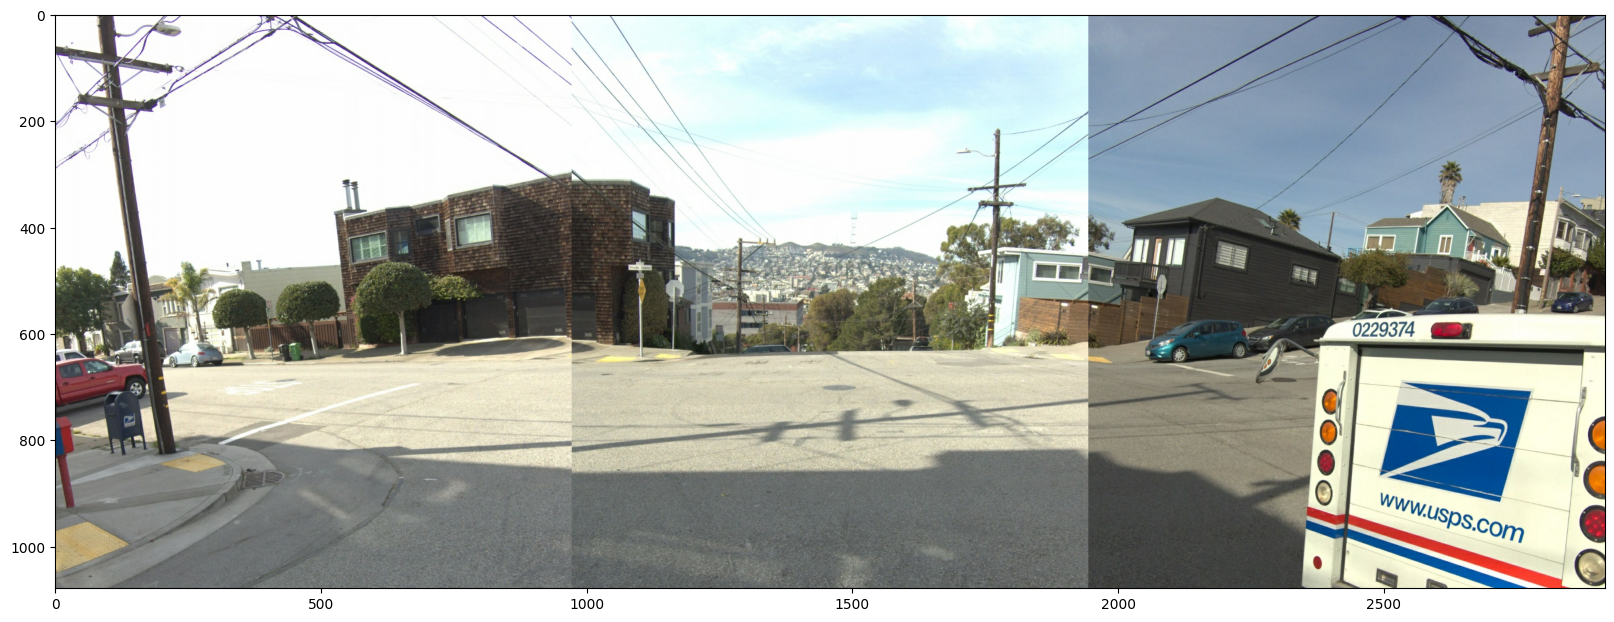

In [67]:
front3_camera_image_list, front3_camera_calibration_list = return_front3_cameras(data)
concatenated_image = np.concatenate(front3_camera_image_list, axis=1)
plt.figure(figsize=(20, 20))
plt.imshow(concatenated_image)

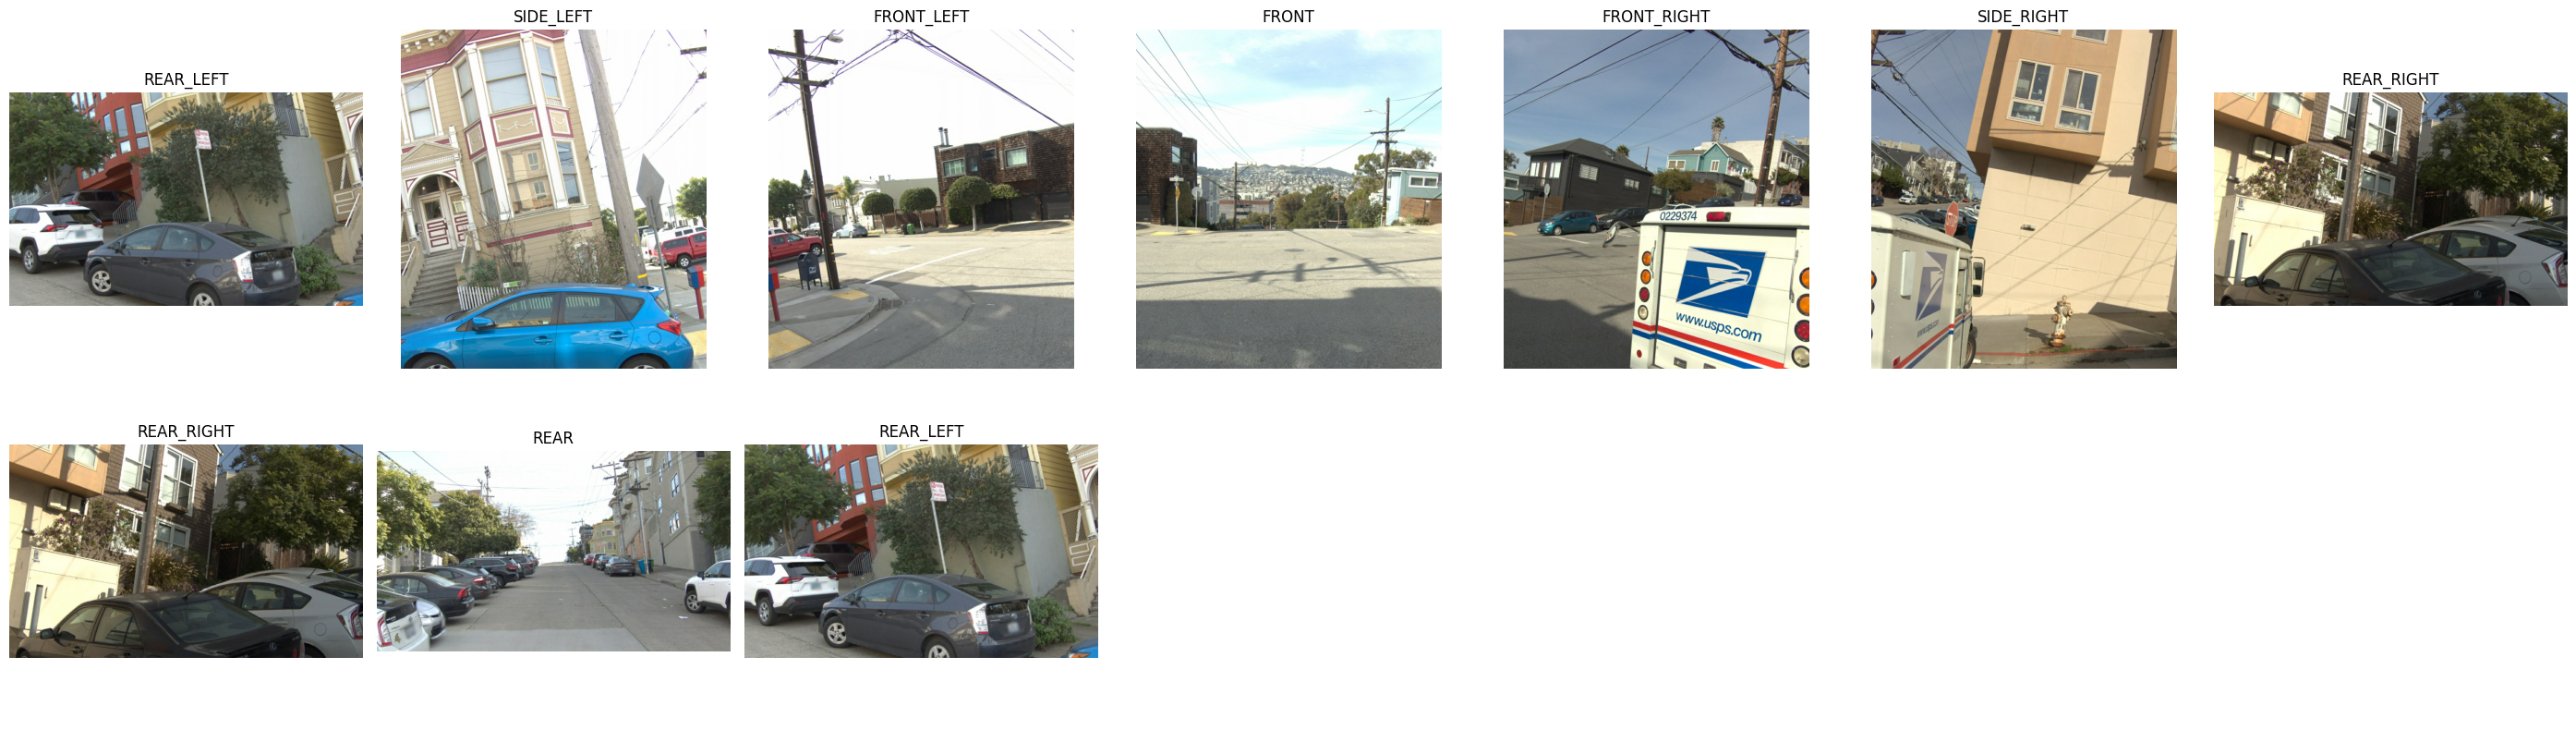

In [76]:
def return_all_cameras(data: wod_e2ed_pb2.E2EDFrame):
    """Return a dict of camera_name -> (image, calibration)"""
    camera_dict = {}

    for index, image_content in enumerate(data.frame.images):
        camera_name = image_content.name
        calibration = data.frame.context.camera_calibrations[index]
        image = tf.io.decode_image(image_content.image).numpy()
        camera_dict[camera_name] = (image, calibration)

    return camera_dict

# Custom order
front_row_order = [6, 4, 2, 1, 3, 5, 8]  # Rear-right to Rear-left, front-focused
back_row_order = [8, 7, 6]                    # Just rear camera

camera_names = {
    1: "FRONT",
    2: "FRONT_LEFT",
    3: "FRONT_RIGHT",
    4: "SIDE_LEFT",
    5: "SIDE_RIGHT",
    6: "REAR_LEFT",
    7: "REAR",
    8: "REAR_RIGHT"
}

# Get camera images
camera_dict = return_all_cameras(data)

# Total number of images
num_cols = max(len(front_row_order), len(back_row_order))
fig, axs = plt.subplots(2, num_cols, figsize=(4 * num_cols, 8))

# Ensure axs is always 2D array-like
axs = np.array(axs).reshape(2, num_cols)

# Fill in front row
for i, cam_id in enumerate(front_row_order):
    image, _ = camera_dict[cam_id]
    axs[0, i].imshow(image)
    axs[0, i].set_title(camera_names[cam_id])
    axs[0, i].axis('off')

# Fill in back row
for i, cam_id in enumerate(back_row_order):
    image, _ = camera_dict[cam_id]
    axs[1, i].imshow(image)
    axs[1, i].set_title(camera_names[cam_id])
    axs[1, i].axis('off')

# Hide unused subplots in second row
for j in range(len(back_row_order), num_cols):
    axs[1, j].axis('off')

plt.tight_layout()
plt.show()

In [10]:
def project_vehicle_to_image(vehicle_pose, calibration, points):
  """Projects from vehicle coordinate system to image with global shutter.

  Arguments:
    vehicle_pose: Vehicle pose transform from vehicle into world coordinate
      system.
    calibration: Camera calibration details (including intrinsics/extrinsics).
    points: Points to project of shape [N, 3] in vehicle coordinate system.

  Returns:
    Array of shape [N, 3], with the latter dimension composed of (u, v, ok).
  """
  # Transform points from vehicle to world coordinate system (can be
  # vectorized).
  pose_matrix = np.array(vehicle_pose.transform).reshape(4, 4)
  world_points = np.zeros_like(points)
  for i, point in enumerate(points):
    cx, cy, cz, _ = np.matmul(pose_matrix, [*point, 1])
    world_points[i] = (cx, cy, cz)

  # Populate camera image metadata. Velocity and latency stats are filled with
  # zeroes.
  extrinsic = tf.reshape(
      tf.constant(list(calibration.extrinsic.transform), dtype=tf.float32),
      [4, 4])
  intrinsic = tf.constant(list(calibration.intrinsic), dtype=tf.float32)
  metadata = tf.constant([
      calibration.width,
      calibration.height,
      open_dataset.CameraCalibration.GLOBAL_SHUTTER,
  ],
                         dtype=tf.int32)
  camera_image_metadata = list(vehicle_pose.transform) + [0.0] * 10

  # Perform projection and return projected image coordinates (u, v, ok).
  return py_camera_model_ops.world_to_image(extrinsic, intrinsic, metadata,
                                            camera_image_metadata,
                                            world_points).numpy()

In [11]:
def draw_points_on_image(image, points, size):
  """Draws points on an image.

  Args:
    image: The image to draw on.
    points: A numpy array of shape (N, 2) representing the points to draw.
  """
  for point in points:
    cv2.circle(image, (int(point[0]), int(point[1])), size, (255, 0, 0), -1)
  return image

Extract the ego vehicle's future trajectory and reshape to (N, 3) matrix.

In [12]:
future_waypoints_matrix = np.stack([data.future_states.pos_x, data.future_states.pos_y, data.future_states.pos_z], axis=1)
print(future_waypoints_matrix)

[[ 3.71337891e-01  7.81250000e-03 -6.37817383e-03]
 [ 7.46704102e-01  1.95312500e-02 -1.01623535e-02]
 [ 1.11755371e+00  3.90625000e-02 -1.10168457e-02]
 [ 1.48071289e+00  5.66406250e-02 -1.08032227e-02]
 [ 1.82653809e+00  7.61718750e-02 -7.44628906e-03]
 [ 2.15319824e+00  9.57031250e-02 -4.02832031e-03]
 [ 2.46057129e+00  1.26953125e-01 -6.37817383e-03]
 [ 2.76306152e+00  1.69921875e-01 -8.54492188e-03]
 [ 3.08544922e+00  2.24609375e-01 -7.53784180e-03]
 [ 3.43554688e+00  2.92968750e-01 -8.30078125e-03]
 [ 3.77978516e+00  3.67187500e-01 -1.08947754e-02]
 [ 4.00573730e+00  4.23828125e-01 -1.73645020e-02]
 [ 4.11303711e+00  4.49218750e-01 -1.81884766e-02]
 [ 4.10668945e+00  4.47265625e-01 -1.99279785e-02]
 [ 4.10058594e+00  4.49218750e-01 -1.98059082e-02]
 [ 4.10058594e+00  4.49218750e-01 -2.05993652e-02]
 [ 4.10058594e+00  4.49218750e-01 -2.06298828e-02]
 [ 4.09960938e+00  4.45312500e-01 -2.05993652e-02]
 [ 4.09912109e+00  4.45312500e-01 -2.06298828e-02]
 [ 4.09814453e+00  4.45312500e-

The pose is always an identity matrix as we already convert world coordinates to vehicle coordinates.

In [13]:
vehicle_pose = data.frame.images[0].pose

We convert the ego vehicle's future waypoints to camera space and draw on camera.

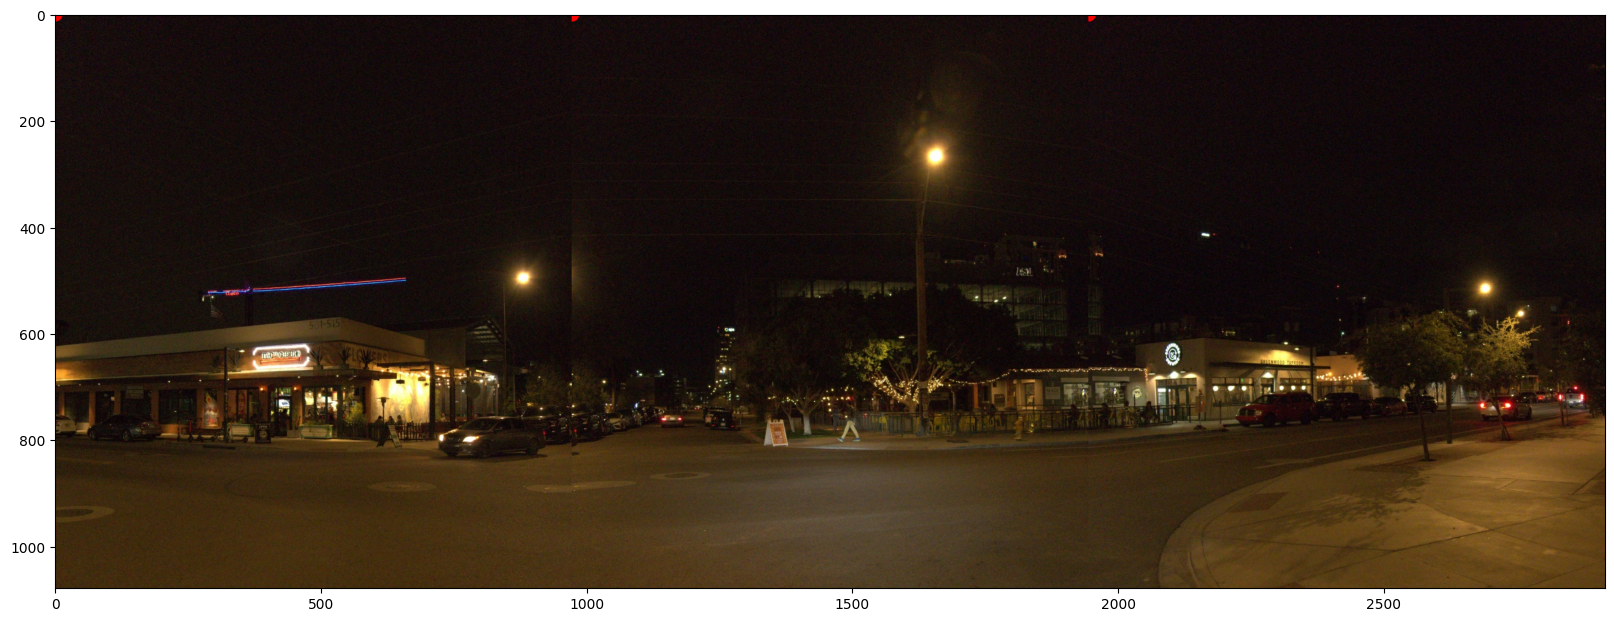

In [14]:
images_with_drawn_points = []
for i in range(len(front3_camera_calibration_list)):
  waypoints_camera_space = project_vehicle_to_image(vehicle_pose, front3_camera_calibration_list[i], future_waypoints_matrix)
  images_with_drawn_points.append(draw_points_on_image(front3_camera_image_list[i], waypoints_camera_space, size=15))
concatenated_image = np.concatenate(images_with_drawn_points, axis=1)
plt.figure(figsize=(20, 20))
plt.imshow(concatenated_image)

## Submission generation

The `wod_e2ed_submission_pb2` defines the proto format of the submission.

The participants are required to produce **a single trajectory** starting after the last provided frame. The trajectory should follow  `TrajectoryPrediction` format and has a length of 5 seconds and a frequency of 4 HZ. Then the participants should add the corresponding frame name to form `FrameTrajectoryPredictions`.  The evaluation server will compute detailed metrics and add them to the leaderboard.

This section will demonstrate how submission file is created

In [15]:
# Assume we have a predicted stopping trajectory.
predicted_trajectory = wod_e2ed_submission_pb2.TrajectoryPrediction(pos_x=np.zeros(20, dtype=np.float32),
                                                                    pos_y=np.zeros(20, dtype=np.float32))
frame_name = data.frame.context.name
frame_trajectory = wod_e2ed_submission_pb2.FrameTrajectoryPredictions(frame_name=frame_name, trajectory=predicted_trajectory)
# The final prediction should be a list of FrameTrajectoryPredictions.
predictions = [frame_trajectory]

In [16]:
# Pack for submission.
num_submission_shards = 1  # Please modify accordingly.
submission_file_base = '/tmp/MySubmission'  # Please modify accordingly.
if not os.path.exists(submission_file_base):
  os.makedirs(submission_file_base)
sub_file_names = [
    os.path.join(submission_file_base, part)
    for part in [f'part{i}' for i in range(num_submission_shards)]
]
# As the submission file may be large, we shard them into different chunks.
submissions = []
num_predictions_per_shard =  math.ceil(len(predictions) / num_submission_shards)
for i in range(num_submission_shards):
  start = i * num_predictions_per_shard
  end = (i + 1) * num_predictions_per_shard
  submissions.append(
      wod_e2ed_submission_pb2.E2EDChallengeSubmission(
          predictions=predictions[start:end]))

In [17]:
for i, shard in enumerate(submissions):
  shard.submission_type  =  wod_e2ed_submission_pb2.E2EDChallengeSubmission.SubmissionType.E2ED_SUBMISSION
  shard.authors[:] = ['A', 'B']  # Please modify accordingly.
  shard.affiliation = 'Affiliation'  # Please modify accordingly.
  shard.account_name = 'acc@domain.com'  # Please modify accordingly.
  shard.unique_method_name = 'YourMethodName'  # Please modify accordingly.
  shard.method_link = 'method_link'  # Please modify accordingly.
  shard.description = ''  # Please modify accordingly.
  shard.uses_public_model_pretraining = True # Please modify accordingly.
  shard.public_model_names.extend(['Model_name']) # Please modify accordingly.
  shard.num_model_parameters = "200k" # Please modify accordingly.
  with tf.io.gfile.GFile(sub_file_names[i], 'wb') as fp:
    fp.write(shard.SerializeToString())

In [18]:
print(submissions[0])

predictions {
  frame_name: "d6cdf6eb1b7d4a8be6dac71f34e6cdb7-164"
  trajectory {
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_x: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
    pos_y: 0
  }
}
submission_type: E2ED_SUBMISSION
account_name: "acc@domain.com"
unique_method_name: "YourMethodName"
authors: "A"
authors: "B"
affiliation: "Affiliation"
description: ""
method_link: "method_link"
uses_public_model_pretraining: true
public_model_names: "Model_name"
num_model_parameters: "200k"



## Package submission
```
cd /tmp
tar cvf MySubmission.tar MySubmission
gzip MySubmission.tar
```
Then you can upload `/tmp/MySubmission.tar.gz` to the challenge website.


## Evaluation
Once the predictions are submitted, our eval server will run the [rater feedback metric](https://waymo.com/intl/en_us/open/challenges/2025/e2e-driving/) to compute the rater feedback scores and update the leaderboard. As the rater feedback metric code won't be released, here we provide a simple ADE Metric implementation to help participants self-evaluate.

In [19]:
def average_distance_per_step(
    predictions , observed_traj, mask
) :
  """Compute L2 distance between proposed trajectories and ground truth.

  Args:
    predictions: A numpy array representing model predictions of size: [# proposals,
      # time steps, spatial features].
    observed_traj: A tensor representing the observed trajectory in the logs of
      size [# time steps, spatial features]
    mask: A boolean tensor representing the time steps that have valid
      observations of size [# time steps].

  Returns:
    A tensor of size [# proposals]
  """
  dist_per_step = np.linalg.norm(
      predictions - observed_traj[np.newaxis], axis=-1
  )
  dist_per_traj = (dist_per_step * mask[np.newaxis]).sum(axis=-1)
  valid_steps = np.maximum(mask.sum(axis=-1, keepdims=True), 1.0)
  avg_distance = dist_per_traj / valid_steps
  return avg_distance


Convert both gt and predictions to a format of dictionary for convenience.

In [20]:
# {frame_name: trajectory}
gt_dict = {}
prediction_dict = {}
gt_dict[data.frame.context.name] =  np.stack([data.future_states.pos_x, data.future_states.pos_y], axis=1)
for submission in submissions:
  for prediction in submission.predictions:
    prediction_dict[prediction.frame_name] = np.stack([prediction.trajectory.pos_x, prediction.trajectory.pos_y], axis=1)

In [21]:
# Compute ADEs. Our ade calculation is generalized to multiple proposal and masking enabled.
ade_list = []
for frame_name in gt_dict:
  if frame_name not in prediction_dict:
    raise ValueError(f'No prediction for {frame_name}')
  gt_traj = gt_dict[frame_name]
  pred_traj = prediction_dict[frame_name]
  mask = np.ones(gt_traj.shape[0], dtype=np.bool_)
  ade_list.append(average_distance_per_step(pred_traj[None], gt_traj, mask)[0])


In [22]:
print(f'ADE: {np.mean(ade_list)}')

ADE: 3.0157173621649456
